In [1]:
%matplotlib inline

# 1) Wipe out your namespace
%reset -f

# 2) Clear Jupyter’s stored outputs and inputs 
try:
    Out.clear() 
except NameError:
    pass

try:
    In.clear()
except NameError:
    pass

# 3) Force Python GC
import gc
gc.collect()

# 4) Free any GPU buffers
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

import importlib
from libs import params, preps, feats, strats, opts, models_core
importlib.reload(params)
importlib.reload(preps)
importlib.reload(feats)
importlib.reload(strats)
importlib.reload(opts)
importlib.reload(models_core)

<module 'libs.models_core' from '/workspace/my_models/Trading/_Stock_Analysis_/libs/models_core.py'>

In [2]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import glob
import os
import json
import re
import psutil
import math
from re import findall

# import time
from pathlib import Path
import pickle
import datetime as dt
from datetime import datetime
from datetime import time

import torch.nn.functional as Funct
from torch.utils.data import Dataset, DataLoader
torch.serialization.add_safe_globals([models_core.DayWindowDataset])

# from tqdm.auto import tqdm
from tqdm import tqdm
import json
from PIL import Image
import IPython.display as disp
from IPython.display import clear_output, display

# Turn off interactive plotting globally (we’ll manage our own display)
import matplotlib
import matplotlib.pyplot as plt
plt.ioff()

import seaborn as sns
from pprint import pprint

import optuna
from optuna.trial import TrialState
from optuna.importance import get_param_importances
from optuna.visualization.matplotlib import plot_optimization_history
from optuna.storages import RDBStorage
from optuna.samplers import TPESampler

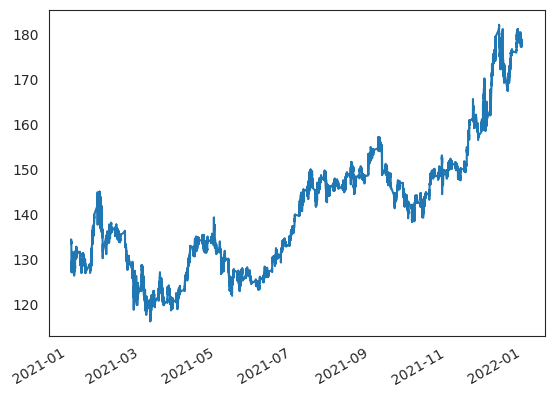

,atr_21_raw,adx_21_raw,rsi_21_raw,vwap_ohlc_close_session_raw,close_raw,targ_signal,signal_thresh,volume,trade_count,ret,sma_pct_21,roc_21,upper_shad,lower_shad,range_pct,rsi_28,atr_pct_7,atr_pct_14,atr_pct_28,plus_di_7,minus_di_7,plus_di_14,minus_di_14,plus_di_21,minus_di_21,plus_di_28,minus_di_28,adx_28,bb_w_20_3p0,bb_w_50_2p0,vol_spike_28,dist_high_100,dist_low_100,ret_std_21,ret_std_63,stoch_d_9_3_3,donch_w_20,donch_w_55,kc_w_20_20_2.0,atr_7_RZ,atr_14_RZ,atr_21_RZ,atr_28_RZ,bb_lband_20_3p0_RZ,bb_lband_50_2p0_RZ,bb_hband_50_2p0_RZ,donch_h_55_RZ,kc_h_20_20_1.5_RZ,kc_h_20_20_2.0_RZ,time_minute,time_hour,time_month,time_day_of_year,time_week_of_year,time_in_sess,time_premark,time_afthour,pred_signal,ask,bid
2021-01-04 08:59:00,0.054745,36.658339,44.383494,133.748956,133.600,0.635409,0.109799,0.001592,0.005609,0.500527,0.453241,0.362361,0.00,0.000000,0.000000,0.445416,0.098884,0.137743,0.152811,0.231631,0.414995,0.206481,0.553814,0.260415,0.589163,0.323034,0.594101,0.424753,0.204514,0.176062,0.229513,0.130485,0.298485,0.162025,0.403526,0.911111,0.181160,0.132061,0.148876,0.101581,0.135311,0.157115,0.181953,0.704074,0.764679,0.280020,0.777778,0.409262,0.394465,0.311806,0.270833,0.500000,0.508219,0.500000,0.0,1.0,0.0,0.093023,133.626720,133.573280
2021-01-04 09:00:00,0.052139,36.361353,44.383494,133.730371,133.600,0.764676,0.113223,0.016739,0.004335,0.500527,0.464569,0.370088,0.00,0.000000,0.000000,0.445416,0.084404,0.127558,0.147036,0.231631,0.414995,0.206481,0.553814,0.260415,0.589163,0.323034,0.594101,0.418513,0.181810,0.176993,1.000000,0.130485,0.298485,0.162374,0.403426,0.955556,0.181160,0.132061,0.141102,0.095604,0.126715,0.148202,0.175565,0.705088,0.762121,0.279779,0.777778,0.408494,0.393585,0.312500,0.312500,0.500000,0.508219,0.500000,0.0,1.0,0.0,0.104469,133.626720,133.573280
2021-01-04 09:01:00,0.061561,34.846448,61.335564,133.730609,133.850,0.153373,0.118619,0.000035,0.002040,1.000000,0.675230,0.494012,0.00,0.000000,0.021672,0.625293,0.165238,0.167333,0.167353,0.676978,0.183484,0.493150,0.388676,0.473909,0.464332,0.498210,0.492027,0.402139,0.181810,0.175212,0.023986,0.050826,0.380685,0.258596,0.417165,0.988889,0.162179,0.131788,0.169364,0.139028,0.153846,0.173879,0.195228,0.705088,0.760705,0.279575,0.777778,0.411448,0.396947,0.313194,0.312500,0.500000,0.508219,0.500000,0.0,1.0,0.0,0.113710,133.876770,133.823230
2021-01-04 09:02:00,0.060058,33.552225,61.824279,133.731450,133.860,0.147660,0.124016,0.000657,0.005609,0.521909,0.683229,0.506407,0.00,0.076923,0.065012,0.630952,0.152473,0.160957,0.164185,0.702612,0.170158,0.518609,0.374010,0.495091,0.451947,0.516437,0.481406,0.387816,0.183971,0.174708,0.079824,0.047646,0.383967,0.258394,0.416984,0.994152,0.171482,0.131778,0.164817,0.134009,0.147749,0.168766,0.191603,0.704946,0.759279,0.279510,0.777778,0.412841,0.398263,0.313889,0.312500,0.500000,0.508219,0.500000,0.0,1.0,0.0,0.105799,133.886772,133.833228
2021-01-04 09:03:00,0.060055,32.488873,62.811405,133.732774,133.880,0.088850,0.118619,0.000999,0.006119,0.543287,0.698826,0.515704,0.28,0.115385,0.130004,0.642347,0.152724,0.160958,0.164257,0.687929,0.145478,0.530908,0.345732,0.508113,0.427765,0.528010,0.460562,0.375683,0.190566,0.175016,0.108677,0.041287,0.390528,0.258821,0.226265,0.977934,0.187755,0.131756,0.164777,0.134813,0.148274,0.167544,0.192204,0.704513,0.755258,0.279554,0.777778,0.414449,0.399862,0.314583,0.312500,0.500000,0.508219,0.500000,0.0,1.0,0.0,0.107648,133.906776,133.853224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 21:55:00,0.007938,9.915792,58.297427,177.800895,177.532,0.031674,0.006953,0.000351,0.003009,0.510199,0.511583,0.519953,0.00,0.000000,0.019608,0.541233,0.011875,0.009476,0.013685,0.492537,0.323053,0.493966,0.349371,0.460790,0.381685,0.409186,0.390561,0.012164,0.007624,0.001711,0.128272,0.

In [3]:
# ###### ML STRATEGIES DF ######

# df_trainval = pd.read_csv(params.pred_trainval_csv, index_col=0, parse_dates=True) #### pred_trainval_csv or pred_test_csv
# df_trainval = df_trainval[(df_trainval.index >= '2021-01-01') & (df_trainval.index < '2021-02-01')] #########################

# df_trainval.close_raw.plot() ; plt.show()
# df_trainval

# Read the Parquet file (schema and datetime index are preserved automatically)
df_opt = pd.read_parquet(params.pred_trainval_pqt) #### pred_trainval_pqt or pred_test_pqt

# Filter dates
df_opt = df_opt[(df_opt.index >= '2021-01-01') & (df_opt.index < '2022-01-01')] #########################

df_opt.close_raw.plot()
plt.show()

df_opt

In [4]:
{'rsi_min_thresh': (44, 58),
 'rsi_max_thresh': (61, 63),
 'adx_thresh': (43.68020006929437, 44.89456993070563),
 'atr_mult': (0.007743095374355835, 0.021176904625644165),
 'vwap_atr_mult': (-7.92342364196164, -6.447056358038361),
 'buy_factor': (0.8975648808518835, 1.0187251191481166),
 'sell_factor': (0.9084736396435489, 1.0125563603564511),
 'trailstop_pct': (1.7151577591835407, 2.593502240816459),
 'thresh_mode': {'categorical': ['roll_median', 'roll_mean']},
 'thresh_window': (252, 328)}

{'rsi_min_thresh': (44, 58),
 'rsi_max_thresh': (61, 63),
 'adx_thresh': (43.68020006929437, 44.89456993070563),
 'atr_mult': (0.007743095374355835, 0.021176904625644165),
 'vwap_atr_mult': (-7.92342364196164, -6.447056358038361),
 'buy_factor': (0.8975648808518835, 1.0187251191481166),
 'sell_factor': (0.9084736396435489, 1.0125563603564511),
 'trailstop_pct': (1.7151577591835407, 2.593502240816459),
 'thresh_mode': {'categorical': ['roll_median', 'roll_mean']},
 'thresh_window': (252, 328)}

In [5]:
col_signal = "pred_signal"

prun_perc = 80 # higher value means the pruner keeps more trials (e.g., 90 keeps the top 10%)
report_interval = 50

def objective(trial: optuna.Trial) -> float:
    rsi_min_thresh   = trial.suggest_int("rsi_min_thresh", 40, 60)
    rsi_max_thresh   = trial.suggest_int("rsi_max_thresh", max(rsi_min_thresh + 1, 60), 70)
    adx_thresh       = trial.suggest_float("adx_thresh", 40, 45)
    atr_mult         = trial.suggest_float("atr_mult", 0.01, 0.03, log=True)
    vwap_atr_mult    = trial.suggest_float("vwap_atr_mult", -10, 10)
    buy_factor       = trial.suggest_float("buy_factor", 0.9, 0.99)
    sell_factor      = trial.suggest_float("sell_factor", 0.9, 0.99)
    trailstop_pct    = trial.suggest_float("trailstop_pct", 1, 3)

    thresh_mode = trial.suggest_categorical("thresh_mode", ["roll_median"])
    
    if thresh_mode == "numeric":
        thresh_mode_num = trial.suggest_float("thresh_mode_num", 0.01, 1.0) 
        thresh_window = None
    else:
        thresh_mode_num = None
        thresh_window = trial.suggest_int("thresh_window", 200, 350) if thresh_mode.startswith("roll") else None

    print('-' * 160)
    print("TRIAL", trial.number, "Params =>", "; ".join(f"{k}={v}" for k, v in dict(trial.params).items()))
    
    df_thresh = preps.apply_thresholds_per_day(
        df = df_opt.copy(),
        col_signal = col_signal,  
        thresh_mode = thresh_mode,
        thresh_window = thresh_window,
        thresh_mode_num = thresh_mode_num
    )

    start_ask = df_thresh.loc[df_thresh.index.normalize() == df_thresh.index.normalize().min(), "ask"].iat[0]
    strats.reset_globals(start_ask)  # necessary to correctly reset the global variables before each independent simulation

    groups = list(df_thresh.groupby(df_thresh.index.normalize()))
    pbar = tqdm(groups, total=len(groups), desc=f"Gen&Sim", leave=True)

    acc = opts.TrialAccumulator(trial, pbar, report_interval=report_interval, prun_perc=prun_perc)
    
    for step, (day, df_day) in enumerate(pbar, 1):

        df_actions = strats.generate_actions(
            df              = df_day,
            col_signal      = col_signal,
            sign_thresh     = "signal_thresh",
            col_atr         = 'atr_21_raw',
            col_adx         = 'adx_21_raw',
            col_rsi         = 'rsi_21_raw',
            col_vwap        = 'vwap_ohlc_close_session_raw',
            col_close       = 'close_raw',
            buy_factor      = buy_factor,
            sell_factor     = sell_factor,
            rsi_min_thresh  = rsi_min_thresh,
            rsi_max_thresh  = rsi_max_thresh,
            adx_thresh      = adx_thresh,
            atr_mult        = atr_mult,
            vwap_atr_mult   = vwap_atr_mult,
            trailstop_pct   = trailstop_pct,
        )

        sim_results = strats.simulate_trading(
            day             = day,
            df              = df_actions
        )
   
        # process results and possibly prune
        acc.process(sim_results, step, parse_eq_value_callable=strats._parse_eq_value)

        # cleanup
        del df_actions, sim_results
        df_day = df_actions = sim_results = None
        
    del df_thresh, groups
    gc.collect()
    # finalize and return objective
    return acc.finalize()


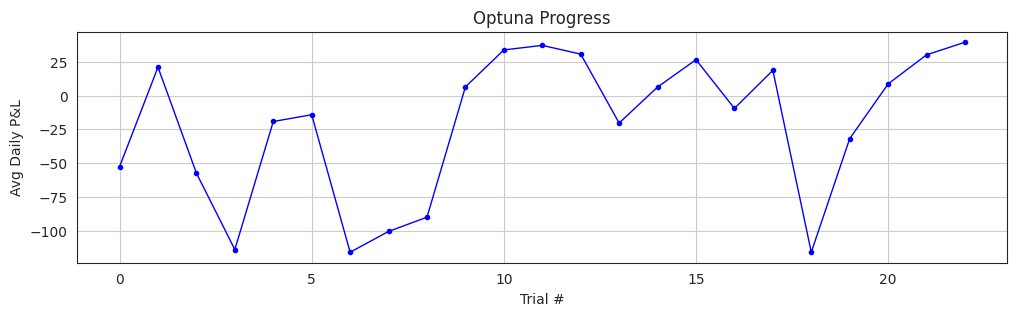

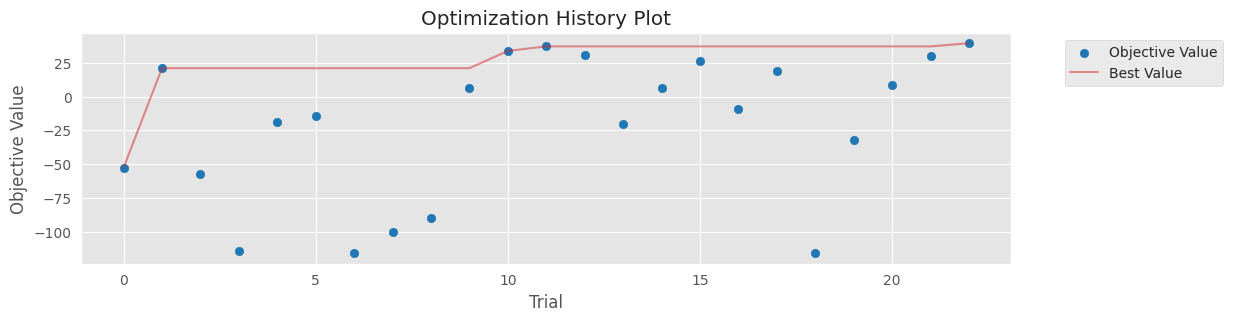

----------------------------------------------------------------------------------------------------------------------------------------------------------------
TRIAL 0 Params => rsi_min_thresh=49; rsi_max_thresh=62; adx_thresh=42.66449396584667; atr_mult=0.015631863572071473; vwap_atr_mult=-0.8179444427580442; buy_factor=0.9069033260367696; sell_factor=0.9525086183458555; trailstop_pct=2.265310872934686; thresh_mode=roll_median; thresh_window=283


Gen&Sim: 100%|██████████| 252/252 [00:12<00:00, 20.44it/s]


[Results] mean_pnl:77.6943 mean_bh:130.4123 mean_excess:-52.7180 improv_vs_bh:-40.42%
Action counts: {'Buy': 128, 'Sell': 179, 'Hold': 220618}
Best trial is: 0 with best_val: -52.7180
[save_results] wrote optuna_results/AAPL_-52.718_pred_ML.csv
[save_best_json] wrote optuna_results/AAPL_-52.718_pred_ML.json
----------------------------------------------------------------------------------------------------------------------------------------------------------------
TRIAL 1 Params => rsi_min_thresh=42; rsi_max_thresh=68; adx_thresh=42.45728021086082; atr_mult=0.015723857498681496; vwap_atr_mult=-7.981577082172979; buy_factor=0.9555468057406816; sell_factor=0.9484671579341799; trailstop_pct=2.1340157573519614; thresh_mode=roll_median; thresh_window=291


Gen&Sim: 100%|██████████| 252/252 [00:12<00:00, 20.99it/s]


[Results] mean_pnl:151.4217 mean_bh:130.4123 mean_excess:21.0094 improv_vs_bh:16.11%
Action counts: {'Buy': 456, 'Sell': 81, 'Hold': 220388}
Best trial is: 1 with best_val: 21.0094
[save_results] wrote optuna_results/AAPL_21.0094_pred_ML.csv
[save_best_json] wrote optuna_results/AAPL_21.0094_pred_ML.json


...

[Results] mean_pnl:169.9013 mean_bh:130.4123 mean_excess:39.4890 improv_vs_bh:30.28%
Action counts: {'Buy': 766, 'Sell': 133, 'Hold': 220026}
Best trial is: 22 with best_val: 39.4890
[save_results] wrote optuna_results/AAPL_39.489_pred_ML.csv
[save_best_json] wrote optuna_results/AAPL_39.489_pred_ML.json


/workspace/my_models/Trading/_Stock_Analysis_/libs/opts.py:187: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(study)


----------------------------------------------------------------------------------------------------------------------------------------------------------------
TRIAL 23 Params => rsi_min_thresh=42; rsi_max_thresh=66; adx_thresh=40.03963387631691; atr_mult=0.023563752402217454; vwap_atr_mult=-7.098390804449395; buy_factor=0.9823431399855785; sell_factor=0.9773000521041758; trailstop_pct=1.1989236425294019; thresh_mode=roll_median; thresh_window=334


Gen&Sim:  70%|██████▉   | 176/252 [00:08<00:03, 20.44it/s]


KeyboardInterrupt: 

In [6]:
# importlib.reload(strats)
# importlib.reload(params)

# Create the two display slots just below the baseline output
opts.init_optuna_displays()

optuna.logging.set_verbosity(optuna.logging.ERROR)

n_trials = 7000
trials_before_pruning = 250
trials_of_exploration = 350

n_days = df_opt.index.normalize().nunique()
reports_per_trial = math.ceil(n_days / report_interval)
n_warmup_steps = math.ceil(reports_per_trial * 0.30)

# sampler = TPESampler(n_startup_trials=trials_of_exploration, multivariate=True)

pruner = optuna.pruners.PercentilePruner(
    percentile=prun_perc,
    n_startup_trials=trials_before_pruning,
    n_warmup_steps=n_warmup_steps,
)

study = optuna.create_study(
    pruner=pruner,
    # sampler=sampler,
    direction="maximize",
)

# Per-run callbacks with suffix "predicted"
cb_save_csv  = opts.make_save_results_callback("pred_ML")
cb_save_json = opts.make_save_best_json_callback("pred_ML")

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[opts.plot_callback, opts.short_log_callback, cb_save_csv, cb_save_json],
    gc_after_trial=True,
)

plt.close("all"); gc.collect()

In [ ]:
!mount | grep /workspace